# Effect of hydrogen enrichment on methane–air combustion

**Computational Methods in Combustion (MKWS), 2026**
Faculty of Power and Aeronautical Engineering (MEiL), Warsaw University of Technology

This notebook studies how blending hydrogen into methane changes three
combustion quantities relevant to an aero gas turbine combustor:

1. **Ignition delay** $\tau_{ign}$
2. **Laminar burning velocity** $S_L$
3. **NOx emission index** EINOx (and the adiabatic flame temperature behind it)

The hydrogen content is defined as a **fraction of the fuel chemical energy**,
which is the meaningful variable for the decarbonisation question. All
chemistry uses **GRI-Mech 3.0**; a separate section validates this choice
against a detailed H$_2$/O$_2$ mechanism.

> The heavy computations are pre-computed and stored as CSV files in
> `../results/data/`. This notebook reloads them so it runs in seconds.
> Cells marked **(slow, optional)** re-run a calculation from scratch.

## 0. Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project modules importable regardless of the working directory
# the notebook is launched from. We look for the 'src' folder next to (or
# one level above) the current directory.
_here = os.getcwd()
for _cand in (os.path.join(_here, "src"),
              os.path.join(_here, "..", "src"),
              _here):
    if os.path.isfile(os.path.join(_cand, "common.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        _root = os.path.abspath(os.path.join(_cand, os.pardir))
        break
else:
    raise RuntimeError("could not locate the project's src/ directory")

import common as cm
cm.apply_plot_style()

DATA = os.path.join(_root, "results", "data")
print("Project root   :", _root)
print("Data directory :", DATA)
print("Mechanism      :", cm.MECHANISM)

Project root   : /tmp/mkws_project
Data directory : /tmp/mkws_project/results/data
Mechanism      : gri30.yaml


## 1. The fuel blend: energy fraction vs mole fraction

Mixing hydrogen and methane on an **energy** basis is not the same as mixing
on a **mole** basis, because the two fuels carry very different heating
values per mole. The table below shows the mole fractions that correspond to
a given hydrogen energy share — note that 30 % of the *energy* from hydrogen
already means almost 60 % of the *moles*.

In [2]:
rows = []
for xe in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]:
    xb = cm.blend_mole_fractions(xe)
    rows.append([100*xe, xb["CH4"], xb["H2"]])
pd.DataFrame(rows, columns=["H2 energy [%]", "X_CH4", "X_H2"]).round(4)

,H2 energy [%],X_CH4,X_H2
0,0.0,1.0000,0.0000
1,10.0,0.7306,0.2694
2,30.0,0.4129,0.5871
3,50.0,0.2316,0.7684
4,70.0,0.1144,0.8856
5,90.0,0.0324,0.9676
6,100.0,0.0000,1.0000


## 2. Ignition delay

Auto-ignition delay in a constant-volume, adiabatic reactor, defined as the
time of maximum temperature-rise rate. We reload the pre-computed sweeps over
temperature, pressure and hydrogen fraction.

In [3]:
ign = pd.read_csv(os.path.join(DATA, "ignition_delay.csv"))
ign.head()

,sweep,phi,x_h2_energy,T0_K,p0_bar,tau_ign_ms
0,T,0.7,0.0,900.0,20.0,294.371890
1,T,0.7,0.0,950.0,20.0,96.987816
2,T,0.7,0.0,1000.0,20.0,36.441980
3,T,0.7,0.0,1050.0,20.0,15.293149
4,T,0.7,0.0,1100.0,20.0,7.039338


### 2a. $\tau_{ign}$ vs temperature (Arrhenius plot)

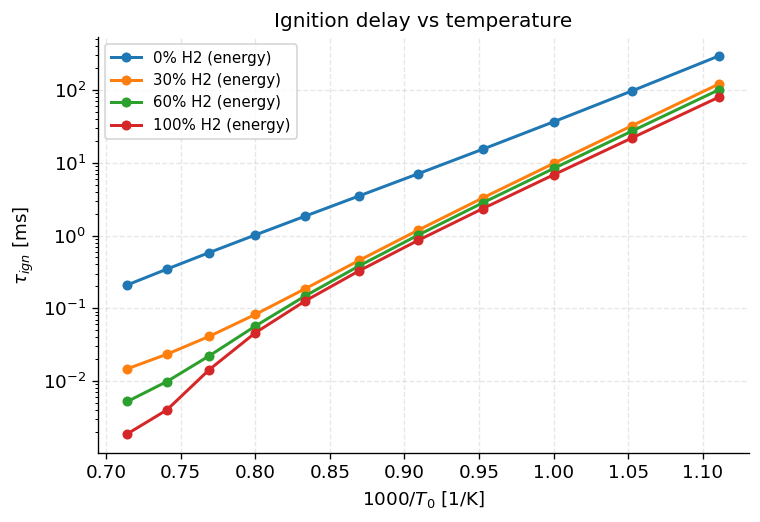

In [4]:
sub = ign[ign["sweep"] == "T"]
fig, ax = plt.subplots()
for xe, g in sub.groupby("x_h2_energy"):
    ax.semilogy(1000.0/g["T0_K"], g["tau_ign_ms"], marker="o",
                label=cm.blend_label(xe))
ax.set_xlabel(r"$1000/T_0$ [1/K]"); ax.set_ylabel(r"$\tau_{ign}$ [ms]")
ax.set_title("Ignition delay vs temperature"); ax.legend(); plt.show()

### 2b. $\tau_{ign}$ vs hydrogen fraction

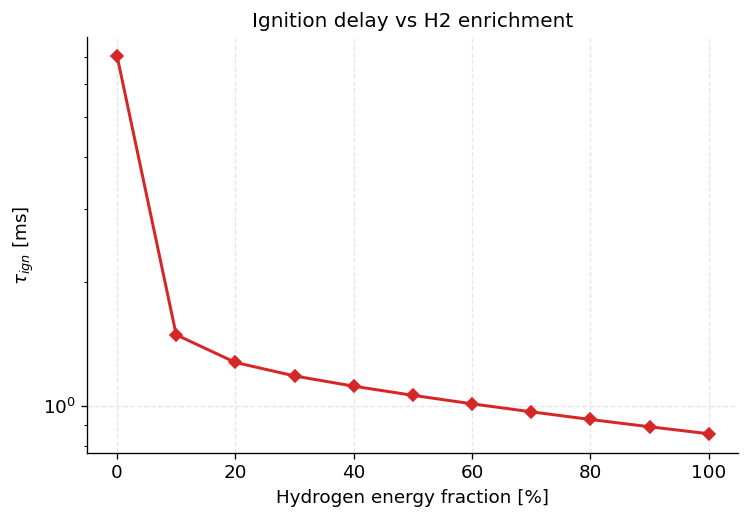

In [5]:
sub = ign[ign["sweep"] == "h2"]
fig, ax = plt.subplots()
ax.semilogy(100*sub["x_h2_energy"], sub["tau_ign_ms"], marker="D", color="C3")
ax.set_xlabel("Hydrogen energy fraction [%]"); ax.set_ylabel(r"$\tau_{ign}$ [ms]")
ax.set_title("Ignition delay vs H2 enrichment"); plt.show()

**(slow, optional)** Recompute a single ignition-delay point to confirm
the stored data.

In [6]:
import ignition_delay as igmod
tau = igmod.ignition_delay(phi=0.7, x_h2_energy=0.5, T0=1100.0, p0=20e5)
print(f"tau_ign(50% H2, 1100 K, 20 bar) = {tau*1e3:.4f} ms")

tau_ign(50% H2, 1100 K, 20 bar) = 1.0603 ms


## 3. Laminar burning velocity

Freely-propagating 1-D premixed flame (`FreeFlame`, mixture-averaged
transport). $S_L$ is the unburned-gas inlet velocity of the converged
solution.

In [7]:
fla = pd.read_csv(os.path.join(DATA, "flame_speed.csv"))
fla.head()

,sweep,phi,x_h2_energy,T0_K,p0_bar,S_L_cm_s
0,phi,0.500000,0.0,450.0,5.0,5.524677
1,phi,0.628571,0.0,450.0,5.0,14.522624
2,phi,0.757143,0.0,450.0,5.0,25.716179
3,phi,0.885714,0.0,450.0,5.0,35.337946
4,phi,1.014286,0.0,450.0,5.0,40.748039


### 3a. $S_L$ vs equivalence ratio

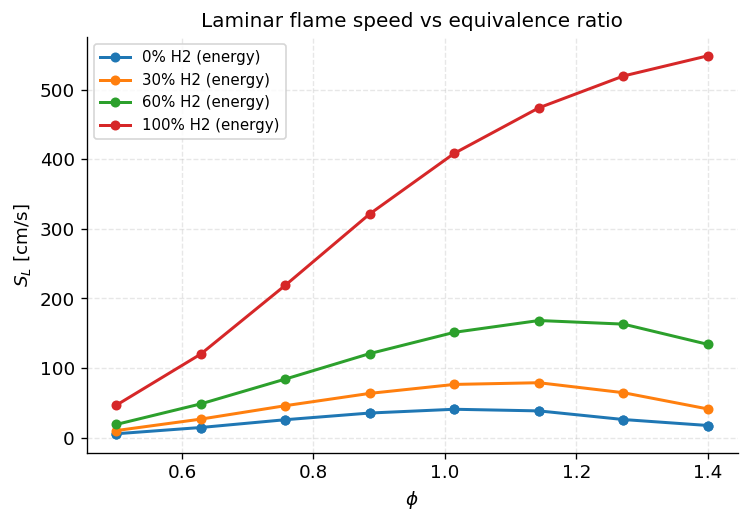

In [8]:
sub = fla[fla["sweep"] == "phi"]
fig, ax = plt.subplots()
for xe, g in sub.groupby("x_h2_energy"):
    g = g.sort_values("phi")
    ax.plot(g["phi"], g["S_L_cm_s"], marker="o", label=cm.blend_label(xe))
ax.set_xlabel(r"$\phi$"); ax.set_ylabel(r"$S_L$ [cm/s]")
ax.set_title("Laminar flame speed vs equivalence ratio"); ax.legend(); plt.show()

### 3b. $S_L$ vs hydrogen fraction (stoichiometric)

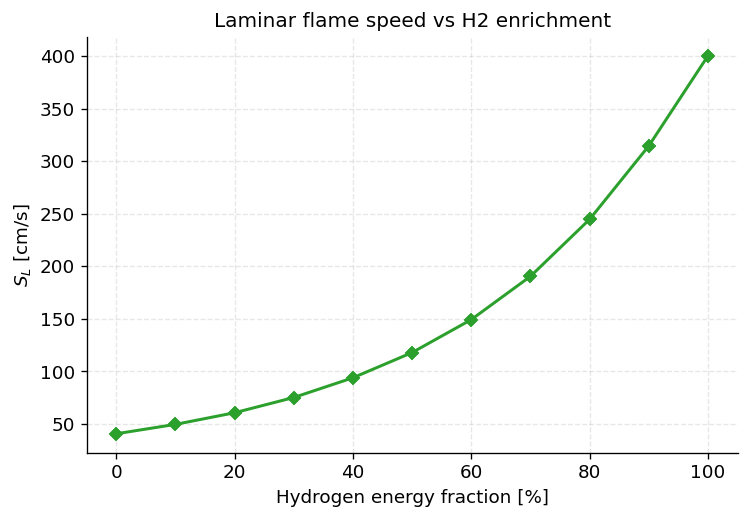

In [9]:
sub = fla[fla["sweep"] == "h2"].sort_values("x_h2_energy")
fig, ax = plt.subplots()
ax.plot(100*sub["x_h2_energy"], sub["S_L_cm_s"], marker="D", color="C2")
ax.set_xlabel("Hydrogen energy fraction [%]"); ax.set_ylabel(r"$S_L$ [cm/s]")
ax.set_title("Laminar flame speed vs H2 enrichment"); plt.show()

## 4. NOx emissions and the flame-temperature trade-off

The burned gas is brought to its constant-pressure equilibrium temperature;
NO is then grown kinetically over a primary-zone residence time. NOx is
reported as an emission index in g(NO$_2$-equivalent) per kg fuel.

In [10]:
nox = pd.read_csv(os.path.join(DATA, "nox_emissions.csv"))
nox.head()

,sweep,phi,x_h2_energy,T0_K,p0_bar,T_ad_K,EINOx_g_per_kg
0,phi,0.5,0.0,700.0,20.0,1799.726534,0.060746
1,phi,0.6,0.0,700.0,20.0,1975.449999,0.992074
2,phi,0.7,0.0,700.0,20.0,2138.869012,8.777552
3,phi,0.8,0.0,700.0,20.0,2288.799409,43.230755
4,phi,0.9,0.0,700.0,20.0,2419.575994,101.342325


### 4a. EINOx vs equivalence ratio

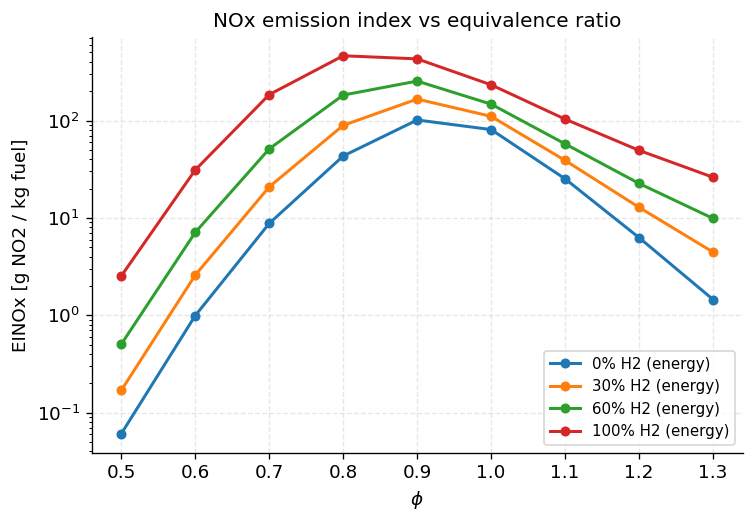

In [11]:
sub = nox[nox["sweep"] == "phi"]
fig, ax = plt.subplots()
for xe, g in sub.groupby("x_h2_energy"):
    g = g.sort_values("phi")
    ax.semilogy(g["phi"], g["EINOx_g_per_kg"], marker="o",
                label=cm.blend_label(xe))
ax.set_xlabel(r"$\phi$"); ax.set_ylabel("EINOx [g NO2 / kg fuel]")
ax.set_title("NOx emission index vs equivalence ratio"); ax.legend(); plt.show()

### 4b. The headline result: NOx / temperature trade-off

Hydrogen raises the flame temperature almost linearly, but thermal NOx
responds *exponentially* to temperature — so a modest temperature rise
produces a large NOx penalty.

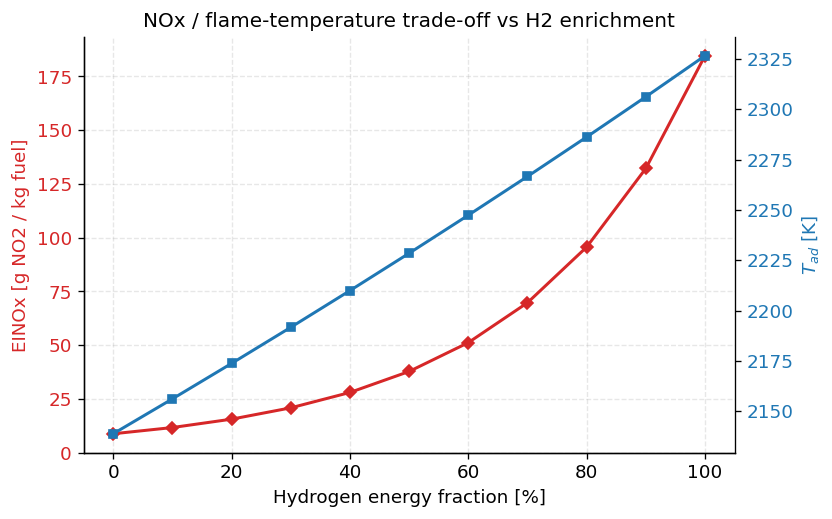

In [12]:
sub = nox[nox["sweep"] == "h2"].sort_values("x_h2_energy")
fig, ax1 = plt.subplots()
ax1.plot(100*sub["x_h2_energy"], sub["EINOx_g_per_kg"], marker="D", color="C3")
ax1.set_xlabel("Hydrogen energy fraction [%]")
ax1.set_ylabel("EINOx [g NO2 / kg fuel]", color="C3")
ax1.tick_params(axis="y", labelcolor="C3")
ax2 = ax1.twinx(); ax2.spines.right.set_visible(True); ax2.grid(False)
ax2.plot(100*sub["x_h2_energy"], sub["T_ad_K"], marker="s", color="C0")
ax2.set_ylabel(r"$T_{ad}$ [K]", color="C0")
ax2.tick_params(axis="y", labelcolor="C0")
ax1.set_title("NOx / flame-temperature trade-off vs H2 enrichment"); plt.show()

## 5. Mechanism validation

GRI-Mech 3.0 is optimised mainly for natural gas. To confirm it is reliable
at the pure-hydrogen end of the blend range, the ignition delay and flame
speed of 100 % H$_2$ are recomputed with a dedicated detailed H$_2$/O$_2$
mechanism and overlaid. Close agreement justifies using a single mechanism
across the whole study.

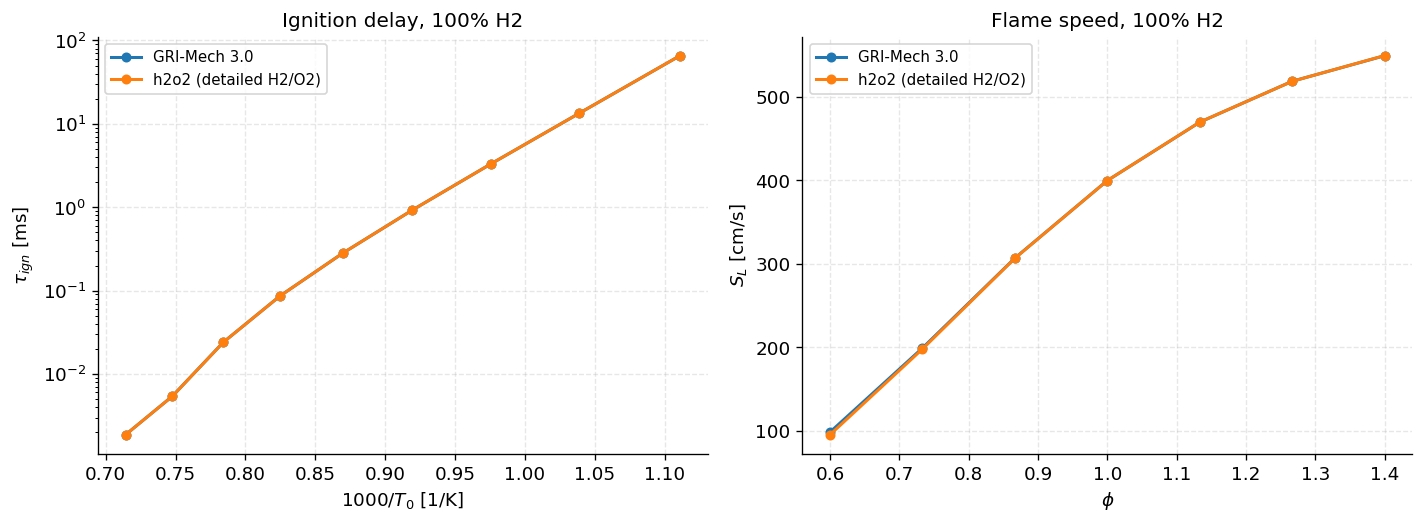

In [13]:
mi = pd.read_csv(os.path.join(DATA, "mech_comparison_ignition.csv"))
mf = pd.read_csv(os.path.join(DATA, "mech_comparison_flame.csv"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, g in mi.groupby("mechanism"):
    axes[0].semilogy(1000.0/g["T0_K"], g["tau_ign_ms"], marker="o", label=label)
axes[0].set_xlabel(r"$1000/T_0$ [1/K]"); axes[0].set_ylabel(r"$\tau_{ign}$ [ms]")
axes[0].set_title("Ignition delay, 100% H2"); axes[0].legend()

for label, g in mf.groupby("mechanism"):
    g = g.sort_values("phi")
    axes[1].plot(g["phi"], g["S_L_cm_s"], marker="o", label=label)
axes[1].set_xlabel(r"$\phi$"); axes[1].set_ylabel(r"$S_L$ [cm/s]")
axes[1].set_title("Flame speed, 100% H2"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Conclusions

- **Ignition:** hydrogen markedly shortens the ignition delay, and the effect
  grows with temperature — beneficial for relight and flame stabilisation.
- **Flame speed:** $S_L$ rises strongly and non-linearly with hydrogen content
  (roughly an order of magnitude from pure CH$_4$ to pure H$_2$).
- **NOx:** the price of hydrogen is a steep, near-exponential rise in thermal
  NOx, driven by the higher flame temperature. Lean operation is the main
  lever to keep NOx acceptable.
- **Mechanism:** GRI-Mech 3.0 agrees closely with a detailed H$_2$/O$_2$
  mechanism for both ignition delay and flame speed at 100 % H$_2$, so it is
  an appropriate single mechanism for the whole blend range.

Overall, hydrogen enrichment improves ignition and burning characteristics
but demands lean, carefully temperature-controlled combustion to manage NOx —
the central trade-off for hydrogen in aero gas turbines.